# Train Rainbow DQN

Rainbow DQN combines six complementary improvements to value-based learning. This notebook trains it on `CartPole-v1` and plots its learning curve.

## Defining idea

$$\text{Rainbow}=\text{Double}+\text{Dueling}+\text{PER}+n\text{-step}+\text{NoisyNet}+\text{C51}.$$

The terms denote Double DQN targets, dueling value heads, prioritized replay (PER), multi-step returns, learned parameter noise, and categorical distributional learning.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from aprenderl import RainbowDQN, RainbowDQNConfig
from aprenderl.utils import evaluate_policy

ENV_ID = "CartPole-v1"

In [2]:
env = gym.make(ENV_ID)
config = RainbowDQNConfig(
    learning_rate=5e-4,
    atoms=51,
    v_min=0.0,
    v_max=200.0,
    n_steps=3,
    buffer_size=15_000,
    batch_size=64,
    learning_starts=500,
    target_update_interval=250,
    seed=7,
)

agent = RainbowDQN(env, config=config, device="cpu")
agent.learn(total_timesteps=15_000, progress_bar=False)
env.close()

/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GTX 960M which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:602: UserWarning: 
NVIDIA

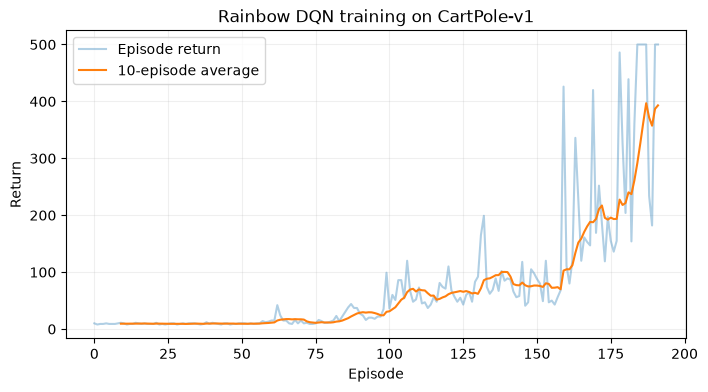

In [3]:
returns = np.asarray(agent.episode_returns)
window = min(10, len(returns))
moving_average = np.convolve(
    returns, np.ones(window) / window, mode="valid"
)

plt.figure(figsize=(8, 4))
plt.plot(returns, alpha=0.35, label="Episode return")
plt.plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode average",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"Rainbow DQN training on {ENV_ID}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Watch the trained policy

This opens a window and runs 5 episodes using deterministic actions.

In [4]:

evaluation_env = gym.make(ENV_ID, render_mode="human")
try:
    result = evaluate_policy(
        agent, evaluation_env, episodes=5, deterministic=True, seed=1_000
    )
finally:
    evaluation_env.close()

print("Episode returns:", result.returns)
print(f"Mean return: {result.mean_return:.1f} +/- {result.return_std:.1f}")

Episode returns: (500.0, 500.0, 500.0, 500.0, 264.0)
Mean return: 452.8 +/- 94.4
